# **Q2: In how many constituencies did the winning party change between 2021 and 2026? Visualise the shifts (a Sankey diagram works well). What pattern emerges?**

## **1) Data Loading**

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [41]:
df2021 = pd.read_csv('tn_2021_results.csv')
df2026 = pd.read_csv('tn_2026_results.csv')
df_master = pd.read_csv('constituency_master.csv')

In [42]:
total_constituencies = df_master['ac_number'].nunique()
print(f"Total number of constituencies: {total_constituencies}")

Total number of constituencies: 234


## **2) Data Prepration (Main Table)**

In [43]:
def get_winning_party(df):
    # Sort by votes in descending order to easily pick the winner
    # Group by 'ac_number' as the official identifier
    df_sorted = df.sort_values(by=['ac_number', 'votes'], ascending=[True, False])
    winners = df_sorted.groupby('ac_number').first().reset_index()
    return winners[['ac_number', 'party']]

# Get winning parties for 2021
winners_2021 = get_winning_party(df2021)
winners_2021.rename(columns={'party': 'winner_2021'}, inplace=True)

# Get winning parties for 2026
winners_2026 = get_winning_party(df2026)
winners_2026.rename(columns={'party': 'winner_2026'}, inplace=True)

# Merge winners_2021 and winners_2026 on 'ac_number'
# Use an outer merge to include all 'ac_number's present in either 2021 or 2026 results
merged_winners = pd.merge(winners_2021, winners_2026, on='ac_number', how='outer')

# Merge with df_master to bring in the constituency name
# We should drop duplicates from df_master if there are any for ac_number to constituency mapping
df_master_unique_ac_map = df_master[['ac_number', 'constituency']].drop_duplicates(subset=['ac_number'])

# Now, merge the merged_winners with the master constituency list
# This ensures that we have the constituency name associated with each ac_number
constituency_flips = pd.merge(df_master_unique_ac_map, merged_winners, on='ac_number', how='left')

# Identify flipped constituencies
# Handle NaN values for winner_2021 or winner_2026 before comparison
constituency_flips['flipped'] = (constituency_flips['winner_2021'].fillna('') != constituency_flips['winner_2026'].fillna(''))

# Display the table
display(constituency_flips.head())

,ac_number,constituency,winner_2021,winner_2026,flipped
0,1,Gummidipundi,DMK,TVK,True
1,2,Ponneri,INC,TVK,True
2,3,Tiruttani,DMK,AIADMK,True
3,4,Thiruvallur,DMK,TVK,True
4,5,Poonamallee,DMK,TVK,True


## **3) Analytical Questions**

#### **Q1. How many constituencies flipped overall?**

In [44]:
# Q1. How many constituencies flipped overall?

num_flipped_constituencies = constituency_flips['flipped'].sum()
print(f"Number of constituencies that flipped: {num_flipped_constituencies}")

Number of constituencies that flipped: 163


#### **Q2: Which party lost the most winning constituencies?**

In [45]:
# Filter for constituencies where the winner flipped
flipped_constituencies_df = constituency_flips[constituency_flips['flipped'] == True]

# Count the number of times each party from 2021 lost in 2026
parties_lost_count = flipped_constituencies_df['winner_2021'].value_counts().reset_index()
parties_lost_count.columns = ['party', 'constituencies_lost']

# Identify the party that lost the most winning constituencies
most_lost_party = parties_lost_count.loc[parties_lost_count['constituencies_lost'].idxmax()]

print(f"The party that lost the most winning constituencies is: {most_lost_party['party']} with {most_lost_party['constituencies_lost']} constituencies lost.")

display(parties_lost_count.head())

The party that lost the most winning constituencies is: DMK with 93 constituencies lost.


,party,constituencies_lost
0,DMK,93
1,AIADMK,44
2,INC,14
3,BJP,4
4,PMK,4


#### **Q3: Which party gained the most flipped constituencies?**

In [46]:
# Filter for constituencies where the winner flipped (already done for Q2, using `flipped_constituencies_df`)

# Count the number of times each party from 2026 won in the flipped constituencies
parties_gained_count = flipped_constituencies_df['winner_2026'].value_counts().reset_index()
parties_gained_count.columns = ['party', 'constituencies_gained']

# Identify the party that gained the most winning constituencies
most_gained_party = parties_gained_count.loc[parties_gained_count['constituencies_gained'].idxmax()]

print(f"The party that gained the most winning constituencies is: {most_gained_party['party']} with {most_gained_party['constituencies_gained']} constituencies gained.")

display(parties_gained_count.head())

The party that gained the most winning constituencies is: TVK with 108 constituencies gained.


,party,constituencies_gained
0,TVK,108
1,AIADMK,25
2,DMK,19
3,PMK,3
4,IUML,2


#### **Q4: Were flips concentrated between specific formations?**

In [47]:
# Create a cross-tabulation of winner_2021 and winner_2026 for flipped constituencies
flips_crosstab = pd.crosstab(flipped_constituencies_df['winner_2021'], flipped_constituencies_df['winner_2026'])

display(flips_crosstab)

winner_2026,AIADMK,AMMK,BJP,CPI(M),DMDK,DMK,INC,IUML,PMK,TVK,VCK
winner_2021,,,,,,,,,,,
AIADMK,0,0,0,0,0,15,1,1,0,26,1
BJP,0,0,0,0,0,2,0,0,0,2,0
CPI(M),0,0,0,0,0,0,0,0,0,1,0
DMK,22,1,0,1,0,0,0,1,3,65,0
INC,0,0,1,0,1,1,0,0,0,11,0
PMK,2,0,0,0,0,0,0,0,0,2,0
VCK,1,0,0,0,0,1,0,0,0,1,0


#### **Q5. Were there stable blocs?**

In [48]:
# Identify constituencies where the winning party did not change
stable_constituencies = constituency_flips[constituency_flips['flipped'] == False]

# Count the number of stable constituencies for each party
stable_blocs_count = stable_constituencies['winner_2021'].value_counts().reset_index()
stable_blocs_count.columns = ['party', 'stable_constituencies']

print(f"Number of constituencies that did not flip: {len(stable_constituencies)}")
print("Stable blocs by party:")
display(stable_blocs_count)

Number of constituencies that did not flip: 71
Stable blocs by party:


,party,stable_constituencies
0,DMK,40
1,AIADMK,22
2,INC,4
3,CPI,2
4,PMK,1
5,VCK,1
6,CPI(M),1


#### **Q6. Most Stable Formation**

In [49]:
# Identify the party with the most stable constituencies
most_stable_formation = stable_blocs_count.loc[stable_blocs_count['stable_constituencies'].idxmax()]

print(f"The most stable formation is: {most_stable_formation['party']} with {most_stable_formation['stable_constituencies']} stable constituencies.")
display(most_stable_formation)

The most stable formation is: DMK with 40 stable constituencies.


,0
party,DMK
stable_constituencies,40


## **4) Visuals**

### **Chart 1: Sankey Diagram for Flipped Constituencies**

In [50]:
# Define the main parties to keep
main_parties = ['TVK', 'DMK', 'AIADMK']

# Function to categorize parties into 'Others' if not in main_parties
def categorize_party(party):
    if party in main_parties:
        return party
    return 'Others'

# Use flipped_constituencies_df which is already filtered for flipped == True
flips_for_sankey = flipped_constituencies_df.copy()

# Apply categorization to winner_2021 and winner_2026 columns for flipped constituencies
flips_categorized = flips_for_sankey.copy()
flips_categorized['winner_2021_cat'] = flips_categorized['winner_2021'].apply(categorize_party)
flips_categorized['winner_2026_cat'] = flips_categorized['winner_2026'].apply(categorize_party)

# Prepare data for Sankey diagram: count transitions from winner_2021_cat to winner_2026_cat
sankey_data = flips_categorized.groupby(['winner_2021_cat', 'winner_2026_cat']).size().reset_index(name='count')

# Get all unique categorized parties to create labels and indices for the nodes
all_parties = pd.concat([sankey_data['winner_2021_cat'], sankey_data['winner_2026_cat']]).unique()
party_to_idx = {party: idx for idx, party in enumerate(all_parties)}

# Create source, target, and value lists for the Sankey diagram
source_nodes = sankey_data['winner_2021_cat'].map(party_to_idx).tolist()
target_nodes = sankey_data['winner_2026_cat'].map(party_to_idx).tolist()
values = sankey_data['count'].tolist()

# Define colors for each party's flows (based on winner_2021_cat)
flow_colors = {
    'DMK': 'rgba(255, 99, 71, 0.6)',  # Soft red
    'AIADMK': 'rgba(0, 0, 255, 0.6)', # Blue
    'TVK': 'rgba(128, 0, 128, 0.6)',  # Purple
    'Others': 'rgba(169, 169, 169, 0.6)' # Grey for others
}

# Create a list of colors for each link based on the source party
link_colors = [flow_colors[row['winner_2021_cat']] for index, row in sankey_data.iterrows()]

# Create the Sankey diagram using Plotly.
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_parties
    ),
    link=dict(
        source=source_nodes,
        target=target_nodes,
        value=values,
        color=link_colors, # Apply the custom link colors
        label=[f"{sankey_data['winner_2021_cat'].iloc[i]} -> {sankey_data['winner_2026_cat'].iloc[i]}: {sankey_data['count'].iloc[i]} constituencies" for i in range(len(sankey_data))]
    )
)])

# Update the layout of the figure with a title, font size, and dimensions for better readability.
fig.update_layout(title_text="Shift in Winning Parties by Constituency (2021 to 2026) - Aggregated Others", font_size=10, width=1200, height=800)
fig.show()

### **Chart 2: Top Transfer Flow Bar Chart**

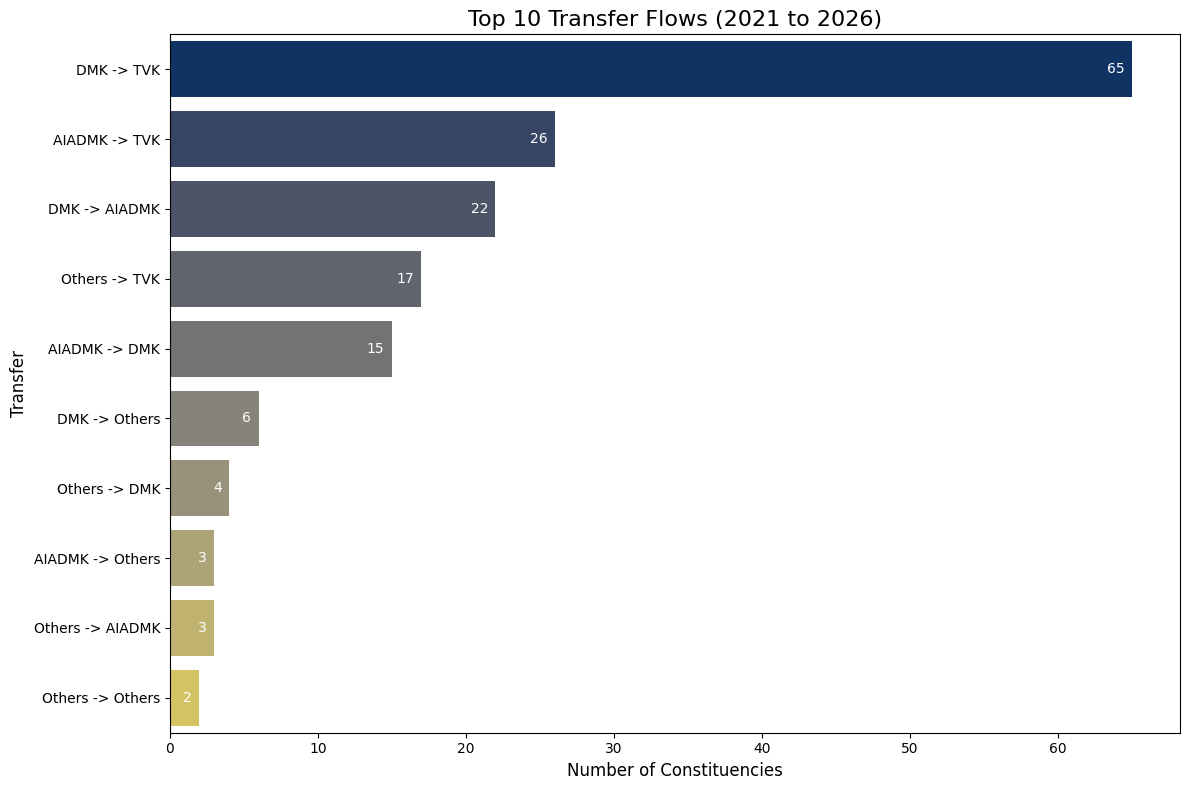

,Constituencies,Transfer
5,65,DMK -> TVK
2,26,AIADMK -> TVK
3,22,DMK -> AIADMK
9,17,Others -> TVK
0,15,AIADMK -> DMK
4,6,DMK -> Others
7,4,Others -> DMK
1,3,AIADMK -> Others
6,3,Others -> AIADMK
8,2,Others -> Others


In [51]:
# Group the categorized flips to get the transfer counts
transfer_counts = flips_categorized.groupby(['winner_2021_cat', 'winner_2026_cat']).size().reset_index(name='Constituencies')

# Create a 'Transfer' column for labeling the bars
transfer_counts['Transfer'] = transfer_counts['winner_2021_cat'] + ' -> ' + transfer_counts['winner_2026_cat']

# Sort by the number of constituencies in descending order
transfer_counts = transfer_counts.sort_values(by='Constituencies', ascending=False)

# Get the top 10 transfers for plotting
top_transfers = transfer_counts.head(10)

# Display the top transfers as a bar chart
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Constituencies', y='Transfer', data=top_transfers, palette='cividis')
plt.title('Top 10 Transfer Flows (2021 to 2026)', fontsize=16)
plt.xlabel('Number of Constituencies', fontsize=12)
plt.ylabel('Transfer', fontsize=12)

# Add numbers inside the bars, right-aligned
for bar in ax.patches:
    x_val = bar.get_width()
    y_val = bar.get_y() + bar.get_height() / 2
    plt.text(x=x_val - 0.5, # Adjust x position to place text inside the bar and right-aligned
             y=y_val,
             s=str(int(x_val)), # Display the exact constituency count from the bar's width
             color='white',
             ha='right', # Horizontal alignment
             va='center', # Vertical alignment
             fontsize=10)

plt.tight_layout()
plt.show()

# Also display the table as requested
display(transfer_counts.head(10).drop(columns=['winner_2021_cat', 'winner_2026_cat']))